In [ ]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("jasonrobinson1/animal-health-incident-reports")

# List all files in the dataset
files = os.listdir(path)

# Load the CSV file (adjust filename if needed)
df = pd.read_csv(os.path.join(path, files[0]))

Using Colab cache for faster access to the 'animal-health-incident-reports' dataset.
Path to dataset files: /kaggle/input/animal-health-incident-reports
Files: ['animal_health_incidents.csv', 'data_dictionary.csv', 'Global_Animal_Health_Incident_Reports.ipynb', 'README.md']


In [ ]:
# Check variables / columns
print("\n--- Shape ---")
print(df.shape)


--- Shape ---
(5579, 13)


In [ ]:
print("\n--- Column Names ---")
print(df.columns.tolist())


--- Column Names ---
['report_id', 'country', 'region', 'date_reported', 'species', 'disease', 'confirmed_cases', 'deaths', 'outbreak_status', 'notes', 'source', 'latitude', 'longitude']


In [ ]:
print("\n--- Data Types ---")
print(df.dtypes)


--- Data Types ---
report_id           object
country             object
region             float64
date_reported       object
species             object
disease             object
confirmed_cases      int64
deaths               int64
outbreak_status     object
notes               object
source              object
latitude           float64
longitude          float64
dtype: object


In [ ]:
print("\n--- First 5 Rows ---")
display(df.head())


--- First 5 Rows ---


,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,NaN,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),0,0,Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,NaN,NaN
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,NaN,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,NaN,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,NaN,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),NaN,2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),0,0,Resolved,First occurrence in the country,https://wahis.woah.org,NaN,NaN


In [ ]:
print("\n--- Basic Stats ---")
display(df.describe(include='all'))


--- Basic Stats ---


,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,source,latitude,longitude
count,5579,5579,0.0,5579,5579,5579,5579.0,5579.0,5579,5579,5579,0.0,0.0
unique,5579,187,NaN,2845,7,141,NaN,NaN,1,14,1,NaN,NaN
top,5062ecd5-aa85-464c-9086-205efb4a5aac,Russia,NaN,2022-06-07,Poultry,High pathogenicity avian influenza viruses (po...,NaN,NaN,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NaN,NaN
freq,1,340,NaN,38,2098,966,NaN,NaN,5579,3696,5579,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
report_id             0
country               0
region             5579
date_reported         0
species               0
disease               0
confirmed_cases       0
deaths                0
outbreak_status       0
notes                 0
source                0
latitude           5579
longitude          5579
dtype: int64


In [ ]:
import requests
import io

# Download World Bank country classification (income group + region)
wb_url = "https://databank.worldbank.org/data/download/site-content/CLASS.xlsx"
wb_response = requests.get(wb_url)
wb_raw = pd.read_excel(io.BytesIO(wb_response.content), sheet_name='List of economies', header=0)

# Keep only relevant columns and clean
wb = wb_raw[['Economy', 'Code', 'Region', 'Income group']].copy()
wb.columns = ['country_wb', 'iso_code', 'wb_region', 'income_group']
wb = wb.dropna(subset=['country_wb'])
wb = wb[wb['income_group'].notna()]  # remove aggregates (continents etc.)

print(f"World Bank data loaded: {len(wb)} countries")
print(wb['income_group'].value_counts())
print(wb['wb_region'].value_counts())

World Bank data loaded: 217 countries
income_group
High income            81
Lower middle income    54
Upper middle income    54
Low income             28
Name: count, dtype: int64
wb_region
Europe & Central Asia         58
Sub-Saharan Africa            48
Latin America & Caribbean     41
East Asia & Pacific           38
Middle East & North Africa    21
South Asia                     8
North America                  3
Name: count, dtype: int64


In [ ]:
name_map = {
    # Original mappings
    "China (People's Rep. of)": "China",
    "United States of America": "United States",
    "Russian Federation": "Russia",
    "Korea (Rep. of)": "Korea, Rep.",
    "Iran (Islamic Rep. of)": "Iran, Islamic Rep.",
    "Taiwan": "Taiwan, China",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Rep. of)": "Venezuela, RB",
    "Tanzania (United Rep. of)": "Tanzania",
    "Congo (Dem. Rep. of the)": "Congo, Dem. Rep.",
    "Congo": "Congo, Rep.",
    "Lao (People's Dem. Rep.)": "Lao PDR",
    "Viet Nam": "Vietnam",
    "Czechia": "Czech Republic",
    "North Macedonia": "North Macedonia",
    "Eswatini": "Eswatini",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Syrian Arab Republic": "Syrian Arab Republic",
    "Libya": "Libya",
    "Kosovo": "Kosovo",

    # Extended mappings
    'Russia': 'Russian Federation',
    'Egypt': 'Egypt, Arab Rep.',
    'Iran': 'Iran, Islamic Rep.',
    'Syria': 'Syrian Arab Republic',
    'Türkiye (Rep. of)': 'Turkiye',
    'Venezuela': 'Venezuela, RB',
    'Slovakia': 'Slovak Republic',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Laos': 'Lao PDR',
    'Brunei': 'Brunei Darussalam',
    'Gambia': 'Gambia, The',
    "Cote D'Ivoire": "Cote d'Ivoire",
    'Congo (Rep. of the)': 'Congo, Rep.',
    'Central African (Rep.)': 'Central African Republic',
    'Dominican (Rep.)': 'Dominican Republic',
    "Korea (Dem People's Rep. of)": "Korea, Dem. People's Rep.",
    'South Sudan (Rep. of)': 'South Sudan',
    'Cabo verde': 'Cabo Verde',
    'Chinese Taipei': 'Taiwan, China',
    'Hong Kong': 'Hong Kong SAR, China',
    'Venezuela' : 'Venezuela, RB',

    # Territories
    'French Guiana': 'France',
    'Guadeloupe': 'France',
    'Martinique': 'France',
    'Reunion': 'France',
    'Mayotte': 'France',
    'Faeroe Islands': 'Denmark',
    'Falkland Islands (Malvinas)': 'United Kingdom',
    'St. Helena': 'United Kingdom',
    'Ceuta': 'Spain',
    'Melilla': 'Spain',
}

df['country_mapped'] = df['country'].replace(name_map)


In [ ]:

df_enriched = df.merge(
    wb[['country_wb', 'iso_code', 'wb_region', 'income_group']],
    left_on='country_mapped',
    right_on='country_wb',
    how='left'
)

# Check merge success rate
total = len(df_enriched)
matched = df_enriched['income_group'].notna().sum()
unmatched = df_enriched[df_enriched['income_group'].isna()]['country'].unique()

print(f"\n✅ Matched: {matched}/{total} ({matched/total*100:.1f}%)")
print(f"\n❌ Unmatched countries ({len(unmatched)}):")
print(sorted(unmatched))


✅ Matched: 5486/5579 (98.3%)

❌ Unmatched countries (7):
['Antarctica', "Cote D'Ivoire", 'Palestine', 'Serbia and Montenegro', 'South Georgia and the South Sandwich Islands', 'Türkiye (Rep. of)', 'Venezuela']


In [ ]:
df_enriched['date_reported'] = pd.to_datetime(df_enriched['date_reported'], errors='coerce')

df_enriched['year'] = df_enriched['date_reported'].dt.year
df_enriched['month'] = df_enriched['date_reported'].dt.month
df_enriched['season'] = df_enriched['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

# ============================================================
# STEP 7: Final check
# ============================================================

print("\n--- Enriched Dataset Info ---")
print(df_enriched[['country', 'wb_region', 'income_group', 'year', 'season']].head(10))
print(f"\nShape: {df_enriched.shape}")
print(f"\nNew columns added: wb_region, income_group, iso_code, year, month, season")


--- Enriched Dataset Info ---
                    country                   wb_region         income_group  \
0                  Mongolia         East Asia & Pacific  Lower middle income   
1                     Niger          Sub-Saharan Africa           Low income   
2                    Israel  Middle East & North Africa          High income   
3                Kazakhstan       Europe & Central Asia  Upper middle income   
4  China (People's Rep. of)         East Asia & Pacific  Upper middle income   
5                    Russia       Europe & Central Asia  Upper middle income   
6                    Russia       Europe & Central Asia  Upper middle income   
7                   Finland       Europe & Central Asia          High income   
8                    Zambia          Sub-Saharan Africa           Low income   
9                   Vietnam         East Asia & Pacific  Lower middle income   

   year  season  
0  2022  Spring  
1  2022  Spring  
2  2022  Spring  
3  2022  Spring 

In [ ]:
df_enriched.head()

,report_id,country,region,date_reported,species,disease,confirmed_cases,deaths,outbreak_status,notes,...,latitude,longitude,country_mapped,country_wb,iso_code,wb_region,income_group,year,month,season
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,NaN,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),0,0,Resolved,First occurrence in a zone or a compartment,...,NaN,NaN,Mongolia,Mongolia,MNG,East Asia & Pacific,Lower middle income,2022,3,Spring
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,NaN,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,...,NaN,NaN,Niger,Niger,NER,Sub-Saharan Africa,Low income,2022,3,Spring
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,NaN,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,0,0,Resolved,Recurrence of an eradicated disease,...,NaN,NaN,Israel,Israel,ISR,Middle East & North Africa,High income,2022,3,Spring
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,NaN,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),0,0,Resolved,Recurrence of an eradicated disease,...,NaN,NaN,Kazakhstan,Kazakhstan,KAZ,Europe & Central Asia,Upper middle income,2022,3,Spring
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),NaN,2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),0,0,Resolved,First occurrence in the country,...,NaN,NaN,China,China,CHN,East Asia & Pacific,Upper middle income,2022,3,Spring


In [ ]:
df_enriched = df_enriched.drop(columns=['region', 'confirmed_cases', 'deaths', 'longitude', 'latitude', 'country_mapped', 'country_wb'])

print(df_enriched.shape)
df_enriched.head()

(5579, 14)


,report_id,country,date_reported,species,disease,outbreak_status,notes,source,iso_code,wb_region,income_group,year,month,season
0,7cda1a50-2034-4b9a-b356-6219c91c13e1,Mongolia,2022-03-08,Unknown,Peste des petits ruminants virus (Inf. with),Resolved,First occurrence in a zone or a compartment,https://wahis.woah.org,MNG,East Asia & Pacific,Lower middle income,2022,3,Spring
1,90e92d52-100a-46e8-9e00-27c3a0eec95f,Niger,2022-03-08,Unknown,Rift Valley fever virus (Inf. with),Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,NER,Sub-Saharan Africa,Low income,2022,3,Spring
2,e6845074-51c6-4f05-adb7-c154ba203999,Israel,2022-03-06,Poultry,High pathogenicity avian influenza viruses (po...,Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,ISR,Middle East & North Africa,High income,2022,3,Spring
3,5ee290fe-e077-4fbb-afe7-924cfbbc5269,Kazakhstan,2022-03-04,Cattle,Foot and mouth disease virus (Inf. with),Resolved,Recurrence of an eradicated disease,https://wahis.woah.org,KAZ,Europe & Central Asia,Upper middle income,2022,3,Spring
4,e9ca57c8-6e8e-4219-89ea-493cb1b1c6d6,China (People's Rep. of),2022-03-04,Unknown,Burkholderia mallei (Inf. with) (Glanders),Resolved,First occurrence in the country,https://wahis.woah.org,CHN,East Asia & Pacific,Upper middle income,2022,3,Spring


Numerical columns: ['year', 'month']

--- Summary Statistics ---


,year,month
count,5579.000000,5579.000000
mean,2017.805521,6.366912
std,5.665689,3.548666
min,2005.000000,1.000000
25%,2014.000000,3.000000
50%,2019.000000,6.000000
75%,2022.000000,10.000000
max,2025.000000,12.000000


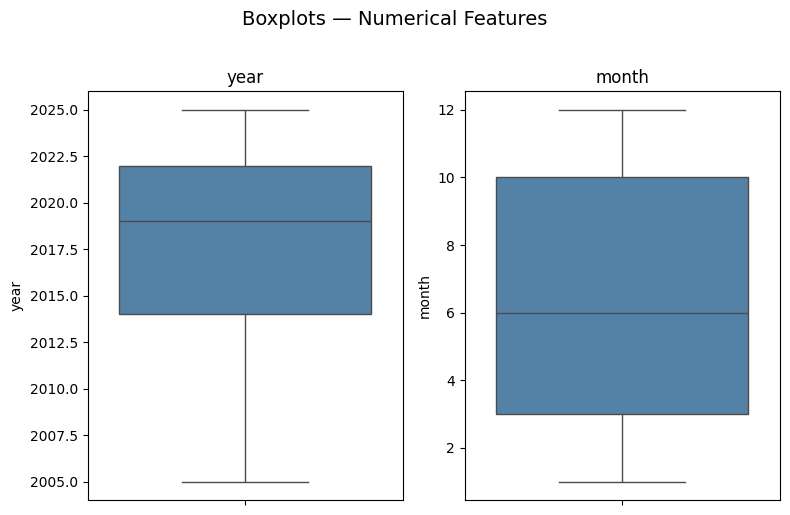


--- IQR Outlier Counts ---
year: 0 outliers (0.0%)
month: 0 outliers (0.0%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Outlier Check — Numerical Columns
# ============================================================

numerical_cols = df_enriched.select_dtypes(include='number').columns.tolist()
print("Numerical columns:", numerical_cols)

# Summary stats
print("\n--- Summary Statistics ---")
display(df_enriched[numerical_cols].describe())

# Boxplots for each numerical column
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4 * len(numerical_cols), 5))

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df_enriched[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.suptitle('Boxplots — Numerical Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# IQR-based Outlier Count per Column
# ============================================================

print("\n--- IQR Outlier Counts ---")
for col in numerical_cols:
    Q1 = df_enriched[col].quantile(0.25)
    Q3 = df_enriched[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_enriched[(df_enriched[col] < Q1 - 1.5 * IQR) | (df_enriched[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_enriched)*100:.1f}%)")

In [ ]:
print(df_enriched['notes'].unique())

['First occurrence in a zone or a compartment'
 'Recurrence of an eradicated disease' 'First occurrence in the country'
 'New strain in the country' 'Emerging disease' 'Unusual host species'
 'Recurrence' 'Recurrence of an eradicated strain'
 'New strain in a zone or a compartment'
 'Listed disease occurring in a new host species'
 'Unexpected change or increase'
 'New pathogen strain or disease manifestation' 'Change in epidemiology'
 'New host']


In [ ]:
print(df_enriched.isnull().sum())
print()
print(f"Total missing: {df_enriched.isnull().sum().sum()}")

report_id           0
country             0
date_reported       0
species             0
disease             0
outbreak_status     0
notes               0
source              0
iso_code           93
wb_region          93
income_group       93
year                0
month               0
season              0
dtype: int64

Total missing: 279


In [ ]:
print(df_enriched.select_dtypes(include='number').columns.tolist())

['year', 'month']


In [ ]:
dist = df_enriched['notes'].value_counts()
pct = df_enriched['notes'].value_counts(normalize=True) * 100

for label in dist.index:
    print(f"{label}: {dist[label]} ({pct[label]:.1f}%)")

Recurrence of an eradicated disease: 3696 (66.2%)
First occurrence in a zone or a compartment: 779 (14.0%)
First occurrence in the country: 266 (4.8%)
Emerging disease: 197 (3.5%)
New strain in the country: 166 (3.0%)
Recurrence: 143 (2.6%)
New strain in a zone or a compartment: 136 (2.4%)
Recurrence of an eradicated strain: 95 (1.7%)
Unusual host species: 42 (0.8%)
Unexpected change or increase: 37 (0.7%)
Change in epidemiology: 7 (0.1%)
Listed disease occurring in a new host species: 6 (0.1%)
New pathogen strain or disease manifestation: 5 (0.1%)
New host: 4 (0.1%)


## Section 1: Missing Value Handling

Fill unmatched `wb_region` and `income_group` with `'Unknown'`. These 93 rows represent territories/disputed regions — dropping them would silently remove real outbreak records.

In [ ]:
# Fill missing wb_region and income_group with 'Unknown'
# (93 rows where country couldn't be matched to World Bank data)
df_enriched['wb_region'] = df_enriched['wb_region'].fillna('Unknown')
df_enriched['income_group'] = df_enriched['income_group'].fillna('Unknown')

# Drop iso_code — not used as a model feature
if 'iso_code' in df_enriched.columns:
    df_enriched = df_enriched.drop(columns=['iso_code'])

# Drop source, report_id, outbreak_status — constant or identifier columns
drop_cols = [c for c in ['source', 'report_id', 'outbreak_status'] if c in df_enriched.columns]
df_enriched = df_enriched.drop(columns=drop_cols)

print('Missing values after filling:')
print(df_enriched.isnull().sum())
print(f'\nShape: {df_enriched.shape}')
print(f'\nColumns remaining: {df_enriched.columns.tolist()}')

Missing values after filling:
country          0
date_reported    0
species          0
disease          0
notes            0
wb_region        0
income_group     0
year             0
month            0
season           0
dtype: int64

Shape: (5579, 10)

Columns remaining: ['country', 'date_reported', 'species', 'disease', 'notes', 'wb_region', 'income_group', 'year', 'month', 'season']


## Section 2: Temporal Train/Test Split

Split by year to respect time ordering and prevent data leakage. All rows from 2005–2021 go to train; 2022–2025 go to test. This mirrors real deployment: predict future events from past patterns.

**Important:** Feature engineering aggregations must be fit on train only and then joined to test — no future information can bleed into training.

In [ ]:
# Temporal train/test split — must happen BEFORE any feature fitting
train_df = df_enriched[df_enriched['year'] <= 2021].copy()
test_df  = df_enriched[df_enriched['year'] >= 2022].copy()

print(f'Train set: {len(train_df)} rows  ({train_df["year"].min()}–{train_df["year"].max()})')
print(f'Test set:  {len(test_df)} rows  ({test_df["year"].min()}–{test_df["year"].max()})')
print(f'\nTrain class distribution:')
print(train_df['notes'].value_counts())
print(f'\nTest class distribution:')
print(test_df['notes'].value_counts())

Train set: 3667 rows  (2005–2021)
Test set:  1912 rows  (2022–2025)

Train class distribution:
notes
Recurrence of an eradicated disease               2465
First occurrence in a zone or a compartment        552
Emerging disease                                   151
First occurrence in the country                    131
New strain in the country                          107
Recurrence                                         101
New strain in a zone or a compartment              100
Unexpected change or increase                       30
Unusual host species                                 9
Change in epidemiology                               7
Listed disease occurring in a new host species       6
New pathogen strain or disease manifestation         5
New host                                             3
Name: count, dtype: int64

Test class distribution:
notes
Recurrence of an eradicated disease            1231
First occurrence in a zone or a compartment     227
First occurrence in th

## Section 3: Feature Engineering

All aggregations are computed **on train only**, then joined to test. This prevents leakage: test rows cannot see their own future counts.

**Features engineered:**
1. `outbreaks_per_country_year` — how active is this country in a given year
2. `outbreaks_per_disease_year` — how widespread is this disease globally in a given year
3. `outbreaks_per_species_year` — how frequently is this species affected in a given year
4. `disease_income` — interaction feature combining disease and income group

In [ ]:
# ── 1. Outbreak frequency aggregations (fit on TRAIN only) ──────────────

# Compute counts per group from training set only
country_year_counts = (
    train_df.groupby(['country', 'year'])
            .size()
            .reset_index(name='outbreaks_per_country_year')
)

disease_year_counts = (
    train_df.groupby(['disease', 'year'])
            .size()
            .reset_index(name='outbreaks_per_disease_year')
)

species_year_counts = (
    train_df.groupby(['species', 'year'])
            .size()
            .reset_index(name='outbreaks_per_species_year')
)

# Join frequency features back to train and test
def add_freq_features(df, country_year_counts, disease_year_counts, species_year_counts):
    df = df.merge(country_year_counts, on=['country', 'year'], how='left')
    df = df.merge(disease_year_counts,  on=['disease', 'year'],  how='left')
    df = df.merge(species_year_counts,  on=['species', 'year'],  how='left')
    # Fill NaN (unseen country/disease/species combos in test) with 0
    df['outbreaks_per_country_year'] = df['outbreaks_per_country_year'].fillna(0)
    df['outbreaks_per_disease_year']  = df['outbreaks_per_disease_year'].fillna(0)
    df['outbreaks_per_species_year']  = df['outbreaks_per_species_year'].fillna(0)
    return df

train_df = add_freq_features(train_df, country_year_counts, disease_year_counts, species_year_counts)
test_df  = add_freq_features(test_df,  country_year_counts, disease_year_counts, species_year_counts)

print('Frequency features added. Sample:')
print(train_df[['country','disease','species','year',
                 'outbreaks_per_country_year','outbreaks_per_disease_year',
                 'outbreaks_per_species_year']].head(10))

Frequency features added. Sample:
        country                                            disease  species  \
0        Latvia              African swine fever virus (Inf. with)    Swine   
1        Latvia  Influenza A viruses of high pathogenicity (Inf...  Poultry   
2        Latvia  Influenza A viruses of high pathogenicity (Inf...  Poultry   
3        France                                            Anthrax  Unknown   
4        Russia  High pathogenicity avian influenza viruses (po...  Poultry   
5        Russia  High pathogenicity avian influenza viruses (po...  Poultry   
6        Russia  Influenza A viruses of high pathogenicity (Inf...  Poultry   
7  Saudi Arabia  Middle East respiratory syndrome coronavirus (...  Unknown   
8         Spain                                            Anthrax  Unknown   
9      Colombia                     Caprine arthritis/encephalitis  Unknown   

   year  outbreaks_per_country_year  outbreaks_per_disease_year  \
0  2021                      

In [ ]:
# ── 2. disease_income interaction feature ─────────────────────────────
# Captures that e.g. ASF in Low income vs High income countries
# may have very different epidemiological profiles

# Use a short disease label to keep the string manageable
# (full disease names are very long — truncate at first parenthesis)
train_df['disease_short'] = train_df['disease'].str.split('(').str[0].str.strip()
test_df['disease_short']  = test_df['disease'].str.split('(').str[0].str.strip()

train_df['disease_income'] = train_df['disease_short'] + '__' + train_df['income_group']
test_df['disease_income']  = test_df['disease_short']  + '__' + test_df['income_group']

print(f'disease_income unique values in train: {train_df["disease_income"].nunique()}')
print(train_df['disease_income'].value_counts().head(10))

disease_income unique values in train: 276
disease_income
High pathogenicity avian influenza viruses__High income            242
High pathogenicity avian influenza viruses__Lower middle income    190
Influenza A viruses of high pathogenicity__High income             173
African swine fever virus__Lower middle income                     161
African swine fever virus__Upper middle income                     153
Low pathogenic avian influenza__High income                        150
Foot and mouth disease virus__Upper middle income                  136
High pathogenicity avian influenza viruses__Upper middle income    109
Newcastle disease virus__High income                               101
Bluetongue virus__High income                                       97
Name: count, dtype: int64


## Section 4: Preprocessing Pipeline (Feature Encoding)


In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Define target and features to encode
TARGET = 'notes'

CATEGORICAL_FEATURES = [
  'country',
  'species',
  'wb_region',
  'income_group',
  'season',
  'disease_short'
]

NUMERIC_FEATURES = [
    'year',
    'month',
    'outbreaks_per_country_year',
    'outbreaks_per_disease_year',
    'outbreaks_per_species_year',
]


# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
        ('num', 'passthrough', NUMERIC_FEATURES)
    ]
)

## Section 5: DummyClassifier Baseline

Always predicts the majority class. This sets the minimum bar every model must beat.

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent'))
])

## Section 6: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

## Section 7: Encode Target

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(train_df[TARGET])

# Filter test set (same as before)
known_classes = set(le.classes_)
test_mask = test_df[TARGET].isin(known_classes)
test_df_filtered = test_df[test_mask].copy()

y_test = le.transform(test_df_filtered[TARGET])

## Section 8: Fit and Evaluate Models (No Tuning)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

# Train + evaluate
evaluate_model(
    "Dummy Classifier",
    dummy_pipeline,
    train_df,
    y_train,
    test_df_filtered,
    y_test
)

evaluate_model(
    "Decision Tree",
    dt_pipeline,
    train_df,
    y_train,
    test_df_filtered,
    y_test
)


=== Dummy Classifier ===
Accuracy : 0.6775
Precision: 0.4590
Recall   : 0.6775
F1-score : 0.5472

=== Decision Tree ===
Accuracy : 0.6313
Precision: 0.5675
Recall   : 0.6313
F1-score : 0.5917


## Section 9: Decision Tree Pipeline (Hyperparameter Tuning)